#### Set-up

In [137]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

#### Data Overview

In [2]:
BASE_DIR=Path("..")/'data'
train_transaction = pd.read_csv(BASE_DIR/'train_transaction.csv')
test_transaction = pd.read_csv(BASE_DIR/'test_transaction.csv')
train_identity = pd.read_csv(BASE_DIR/'train_identity.csv')
test_identity = pd.read_csv(BASE_DIR/'test_identity.csv')

In [3]:
# Sanity check before joining
# This shows the percentage of transactions that have identity data.
overlap = train_transaction['TransactionID'].isin(train_identity['TransactionID']).mean()
print(f"Transactions that have identity data: {overlap:.2%}")

# If this returns 0, every transaction has at most ONE identity row
duplicates = train_identity['TransactionID'].duplicated().sum()
print(f"Number of duplicate IDs: {duplicates}")

Transactions that have identity data: 24.42%
Number of duplicate IDs: 0


In [4]:
# Combine train and test
# All identity columns are NaN after joining (Only 24.42% are present in Transaction)
df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [5]:
# Clear memory
del train_transaction, test_transaction, train_identity, test_identity

In [6]:
print(f'Train: {df_train.shape[0]} rows and {df_train.shape[1]} columns')
print(f'Test: {df_test.shape[0]} rows and {df_test.shape[1]} columns')

Train: 590540 rows and 434 columns
Test: 506691 rows and 433 columns


In [7]:
df_train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [8]:
df_test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Calculate the proportion of NAs for every column (returns a decimal between 0.0 and 1.0)
na_count = df_train.isna().mean()

# Filter for only the columns that are missing 50% or more of their data
missing_50_plus = na_count[na_count >= 0.50]

# Sort them in descending order so the emptiest columns are at the top
#missing_50_labels = missing_50_plus.sort_values(ascending=False)

print(f'Total missing values above 50%: {len(missing_50_plus)} out of {len(df_train.columns)}')
#print(missing_50_labels.head(5)*100)

Total missing values above 50%: 214 out of 434


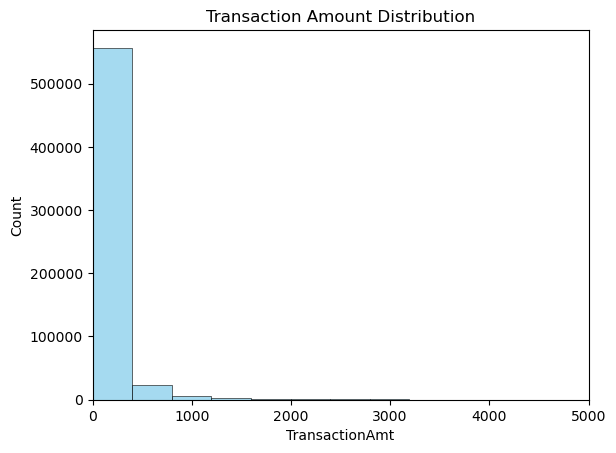

In [90]:
ax = sns.histplot(
    data = df_train,
    x = 'TransactionAmt',
    bins=80,
    color='skyblue'
    )

ax.set_xlim(0, 5000)

plt.title("Transaction Amount Distribution")
plt.show()

In [11]:
print(df_train['TransactionAmt'].skew().round(2))

14.37


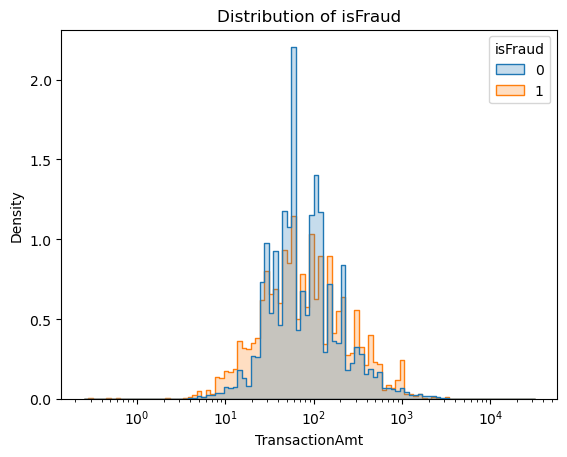

In [96]:
sns.histplot(
    data=df_train,
    x='TransactionAmt',
    hue='isFraud',
    bins=100,
    element='step',
    stat='density', #Normalize the counts (class imbalance)
    common_norm=False,
    log_scale=True
)

plt.title("Distribution of isFraud")
plt.show()

The log-transformed transaction amounts show that fraudulent transactions are more concentrated in very low and unusual high ranges, whereas most legitimate transactions cluster in mid-range amounts. While the log transformation reduces skewness and allows better visualization, there is still considerable overlap between fraud and non-fraud transactions. This suggests that TransactionAmt is moderately predictive but not sufficient for reliable fraud detection on its own.

In [131]:
# Create a dummy column: 1 if we have identity data, 0 if we don't
df_train['has_identity'] = df_train['id_01'].notnull().astype(int)

fraud_with_id = df_train.groupby('has_identity')['isFraud'].mean()
print(f"Fraud rate with identity info: {fraud_with_id[1]:.2%}")
print(f"Fraud rate without identity info: {fraud_with_id[0]:.2%}")

del df_train['has_identity']

Fraud rate with identity info: 7.85%
Fraud rate without identity info: 2.09%


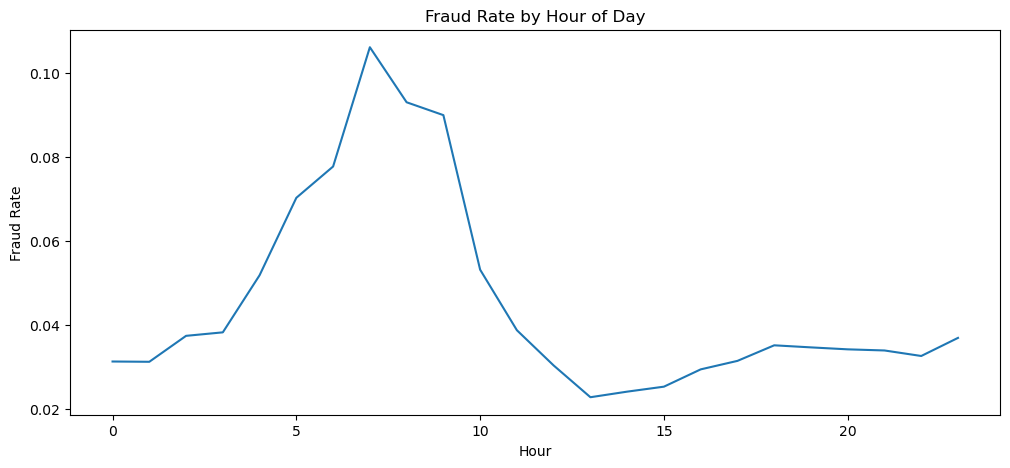

In [ ]:
# Assuming TransactionDT starts at 0 (Midnight)
df_train['hours'] = (df_train['TransactionDT'] // 3600) % 24

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_train.groupby('hours')['isFraud'].mean())

plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate')
plt.xlabel('Hour')
plt.show()

#### IDs

In [ ]:
# List of all ID columns
id_cols = [f'id_{i:02d}' for i in range(1, 39)]

for col in id_cols:
    if col in df_train.columns:
        # Check how many unique values and how much is missing
        null_percentage = df_train[col].isnull().mean() * 100
        unique_count = df_train[col].nunique()
        col_type = df_train[col].dtype
        print(f"{col}: {unique_count} unique values | {null_percentage:.1f}% Missing | {col_type}")

id_01: 77 unique values | 75.6% Missing | float64
id_02: 115655 unique values | 76.1% Missing | float64
id_03: 24 unique values | 88.8% Missing | float64
id_04: 15 unique values | 88.8% Missing | float64
id_05: 93 unique values | 76.8% Missing | float64
id_06: 101 unique values | 76.8% Missing | float64
id_07: 84 unique values | 99.1% Missing | float64
id_08: 94 unique values | 99.1% Missing | float64
id_09: 46 unique values | 87.3% Missing | float64
id_10: 62 unique values | 87.3% Missing | float64
id_11: 365 unique values | 76.1% Missing | float64
id_12: 2 unique values | 75.6% Missing | object
id_13: 54 unique values | 78.4% Missing | float64
id_14: 25 unique values | 86.4% Missing | float64
id_15: 3 unique values | 76.1% Missing | object
id_16: 2 unique values | 78.1% Missing | object
id_17: 104 unique values | 76.4% Missing | float64
id_18: 18 unique values | 92.4% Missing | float64
id_19: 522 unique values | 76.4% Missing | float64
id_20: 394 unique values | 76.4% Missing | float

- id_07, id_08, and id_21 through id_27 have over 99% missing data.
- id_02 has 115655 unique values, an outlier compared to the other ids.
- id_32 has 4 unique values and is listed as a float, meaning it could be a categorical feature that is using numbers as bins.